In [1]:
import numpy as np

CODON_TABLE = {
    "TTT": "F", "TTC": "F", "TTA": "L", "TTG": "L",
    "CTT": "L", "CTC": "L", "CTA": "L", "CTG": "L",
    "ATT": "I", "ATC": "I", "ATA": "I", "ATG": "M",
    "GTT": "V", "GTC": "V", "GTA": "V", "GTG": "V",
    "TCT": "S", "TCC": "S", "TCA": "S", "TCG": "S",
    "CCT": "P", "CCC": "P", "CCA": "P", "CCG": "P",
    "ACT": "T", "ACC": "T", "ACA": "T", "ACG": "T",
    "GCT": "A", "GCC": "A", "GCA": "A", "GCG": "A",
    "TAT": "Y", "TAC": "Y", "TAA": "*", "TAG": "*",
    "CAT": "H", "CAC": "H", "CAA": "Q", "CAG": "Q",
    "AAT": "N", "AAC": "N", "AAA": "K", "AAG": "K",
    "GAT": "D", "GAC": "D", "GAA": "E", "GAG": "E",
    "TGT": "C", "TGC": "C", "TGA": "*", "TGG": "W",
    "CGT": "R", "CGC": "R", "CGA": "R", "CGG": "R",
    "AGT": "S", "AGC": "S", "AGA": "R", "AGG": "R",
    "GGT": "G", "GGC": "G", "GGA": "G", "GGG": "G",
}

PHYSICOCHEMICAL_GROUPS = {
    "A": "nonpolar", "V": "nonpolar", "I": "nonpolar", "L": "nonpolar",
    "M": "nonpolar", "F": "nonpolar", "W": "nonpolar", "P": "nonpolar",
    "G": "polar",    "S": "polar",    "T": "polar",    "C": "polar",
    "Y": "polar",    "N": "polar",    "Q": "polar",
    "D": "acidic",   "E": "acidic",
    "K": "basic",    "R": "basic",    "H": "basic",
}

HBOND_GROUPS = {
    "A": 2, "T": 2,
    "G": 3, "C": 3,
}

def translate_motif(motif):
    amino_acids = []
    for i in range(0, len(motif), 3):
        codon = motif[i:i+3]
        amino_acids.append(CODON_TABLE.get(codon, "?"))
    return amino_acids

def compute_fitness_nucleotide(chromosome, sequences, motif_length):
    motifs = [seq[pos: pos + motif_length] for seq, pos in zip(sequences, chromosome)]
    PFM = np.zeros((4, motif_length))
    for motif in motifs:
        for col, char in enumerate(motif):
            if char == "A": PFM[0, col] += 1
            elif char == "T": PFM[1, col] += 1
            elif char == "C": PFM[2, col] += 1
            elif char == "G": PFM[3, col] += 1
    return sum(max(PFM[:, col]) for col in range(motif_length))

def compute_fitness_aminoacid(chromosome, sequences, motif_length):
    motifs = [seq[pos: pos + motif_length] for seq, pos in zip(sequences, chromosome)]
    translated = [translate_motif(motif) for motif in motifs]
    num_codons = motif_length // 3
    score = 0
    for col in range(num_codons):
        col_aas = [t[col] for t in translated]
        counts = {}
        for aa in col_aas:
            counts[aa] = counts.get(aa, 0) + 1
        score += max(counts.values())
    return score

def compute_fitness_physicochemical(chromosome, sequences, motif_length):
    motifs = [seq[pos: pos + motif_length] for seq, pos in zip(sequences, chromosome)]
    translated = [translate_motif(motif) for motif in motifs]
    num_codons = motif_length // 3
    score = 0
    for col in range(num_codons):
        col_aas = [t[col] for t in translated]
        counts = {}
        for aa in col_aas:
            group = PHYSICOCHEMICAL_GROUPS.get(aa, "unknown")
            counts[group] = counts.get(group, 0) + 1
        score += max(counts.values())
    return score

def compute_fitness_hbond(chromosome, sequences, motif_length):
    motifs = [seq[pos: pos + motif_length] for seq, pos in zip(sequences, chromosome)]
    score = 0
    for col in range(motif_length):
        counts = {}
        for motif in motifs:
            group = HBOND_GROUPS.get(motif[col], -1)
            counts[group] = counts.get(group, 0) + 1
        score += max(counts.values())
    return score

def compute_fitness(chromosome, sequences, motif_length):
    if FITNESS_MODE == "nucleotide":
        return compute_fitness_nucleotide(chromosome, sequences, motif_length)
    elif FITNESS_MODE == "aminoacid":
        return compute_fitness_aminoacid(chromosome, sequences, motif_length)
    elif FITNESS_MODE == "physicochemical":
        return compute_fitness_physicochemical(chromosome, sequences, motif_length)
    elif FITNESS_MODE == "hbond":
        return compute_fitness_hbond(chromosome, sequences, motif_length)
    else:
        raise ValueError(f"Unknown FITNESS_MODE: '{FITNESS_MODE}'. Choose from: 'nucleotide', 'aminoacid', 'physicochemical', 'hbond'.")

In [2]:
import random
random.seed(42)
np.random.seed(42)

def initialize_population(pop_size, sequences, motif_length):
    population = [[random.randint(0, len(seq) - motif_length) for seq in sequences] for _ in range(pop_size)]
    return population

In [3]:
def compute_all_fitnesses(chromosome, sequences, motif_length):
    return (
        compute_fitness_nucleotide(chromosome, sequences, motif_length),
        compute_fitness_aminoacid(chromosome, sequences, motif_length),
        compute_fitness_physicochemical(chromosome, sequences, motif_length),
        compute_fitness_hbond(chromosome, sequences, motif_length),
    )

def dominates(a, b):
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def non_dominated_sort(fitnesses):
    n = len(fitnesses)
    dominated_by = [[] for _ in range(n)]   # who dominates i
    domination_count = [0] * n              # how many dominate i
    fronts = [[]]

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            if dominates(fitnesses[i], fitnesses[j]):
                dominated_by[i].append(j)
            elif dominates(fitnesses[j], fitnesses[i]):
                domination_count[i] += 1
        if domination_count[i] == 0:
            fronts[0].append(i)

    current_front = 0
    while fronts[current_front]:
        next_front = []
        for i in fronts[current_front]:
            for j in dominated_by[i]:
                domination_count[j] -= 1
                if domination_count[j] == 0:
                    next_front.append(j)
        current_front += 1
        fronts.append(next_front)

    return [f for f in fronts if f]

def crowding_distance(front_indices, fitnesses):
    n = len(front_indices)
    distances = {i: 0.0 for i in front_indices}
    num_objectives = len(fitnesses[0])

    for obj in range(num_objectives):
        sorted_front = sorted(front_indices, key=lambda i: fitnesses[i][obj])
        f_min = fitnesses[sorted_front[0]][obj]
        f_max = fitnesses[sorted_front[-1]][obj]
        span = f_max - f_min if f_max != f_min else 1e-9

        distances[sorted_front[0]] = float("inf")
        distances[sorted_front[-1]] = float("inf")

        for k in range(1, n - 1):
            distances[sorted_front[k]] += (
                fitnesses[sorted_front[k + 1]][obj] - fitnesses[sorted_front[k - 1]][obj]
            ) / span

    return distances

def pareto_tournament_select(population, ranks, crowding, tournament_size=3):
    candidates = random.sample(range(len(population)), tournament_size)
    winner = candidates[0]
    for c in candidates[1:]:
        if ranks[c] < ranks[winner]:
            winner = c
        elif ranks[c] == ranks[winner] and crowding[c] > crowding[winner]:
            winner = c
    return population[winner]

In [4]:
def mutate(chromosome, sequences, motif_length, mutation_rate=0.3):
    if random.random() < mutation_rate:
        i = random.randint(0, len(chromosome) - 1)
        chromosome = chromosome[:]
        chromosome[i] = random.randint(0, len(sequences[i]) - motif_length)
    return chromosome

In [5]:
def crossover(parent_a, parent_b, crossover_rate=0.3):
    n = len(parent_a)
    segment_length = max(1, int(crossover_rate * n))
    start = random.randint(0, n - segment_length)
    end = start + segment_length

    child_a = parent_a[:start] + parent_b[start:end] + parent_a[end:]
    child_b = parent_b[:start] + parent_a[start:end] + parent_b[end:]

    return child_a, child_b

In [6]:
def write_to_txt (string, filename):
    with open(filename, "a") as f:
        f.write(string + "\n")
def read_txt_and_return_lines(filename):
    with open(filename, "r") as f:
        lines = [line.strip() for line in f]
    return lines

In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def run_ga_pareto(population, sequences, motif_length, num_generations,
                  tournament_size, mutation_rate, elite_count):
    OBJECTIVE_NAMES = ["Nucleotide", "Amino Acid", "Physicochemical", "H-Bond"]

    history = {name: {"best": [], "avg": []} for name in OBJECTIVE_NAMES}

    for gen in range(num_generations):
        fitnesses = [compute_all_fitnesses(ind, sequences, motif_length) for ind in population]
        fronts = non_dominated_sort(fitnesses)
        ranks = [0] * len(population)
        for rank, front in enumerate(fronts):
            for idx in front:
                ranks[idx] = rank

        crowding = {}
        for front in fronts:
            crowding.update(crowding_distance(front, fitnesses))

        for obj_idx, name in enumerate(OBJECTIVE_NAMES):
            obj_scores = [f[obj_idx] for f in fitnesses]
            history[name]["best"].append(max(obj_scores))
            history[name]["avg"].append(sum(obj_scores) / len(obj_scores))

        front0_sorted = sorted(fronts[0], key=lambda i: crowding[i], reverse=True)
        elites = [population[i] for i in front0_sorted[:elite_count]]
        new_population = elites[:]

        while len(new_population) < len(population):
            parent_a = pareto_tournament_select(population, ranks, crowding, tournament_size)
            parent_b = pareto_tournament_select(population, ranks, crowding, tournament_size)
            child_a, child_b = crossover(parent_a, parent_b)
            mutated_a = mutate(child_a, sequences, motif_length, mutation_rate)
            mutated_b = mutate(child_b, sequences, motif_length, mutation_rate)
            new_population.append(mutated_a)
            if len(new_population) < len(population):
                new_population.append(mutated_b)

        population = new_population

    fitnesses = [compute_all_fitnesses(ind, sequences, motif_length) for ind in population]
    fronts = non_dominated_sort(fitnesses)

    pareto_front_chromosomes = [population[i] for i in fronts[0]]
    pareto_front_fitnesses   = [fitnesses[i]  for i in fronts[0]]

    return pareto_front_chromosomes, pareto_front_fitnesses, history


def plot_pareto_convergence(history, motif_length, num_generations, sequences):
    OBJECTIVE_NAMES = ["Nucleotide", "Amino Acid", "Physicochemical", "H-Bond"]
    COLORS = ["royalblue", "tomato", "seagreen", "darkorange"]

    max_possibles = {
        "Nucleotide":       motif_length * len(sequences),
        "Amino Acid":       (motif_length // 3) * len(sequences),
        "Physicochemical":  (motif_length // 3) * len(sequences),
        "H-Bond":           motif_length * len(sequences),
    }

    generations = list(range(1, num_generations + 1))
    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    axes = axes.flatten()

    for ax, name, color in zip(axes, OBJECTIVE_NAMES, COLORS):
        ax.plot(generations, history[name]["best"], label="Best", color=color, linewidth=2)
        ax.axhline(y=max_possibles[name], color="green", linestyle=":", linewidth=1,
                   label=f"Max ({max_possibles[name]})")
        ax.set_title(f"{name} Objective")
        ax.set_xlabel("Generation")
        ax.set_ylabel("Fitness Score")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle(f"NSGA-II Pareto GA — Motif Length {motif_length}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("pareto_convergence.png", dpi=150)
    plt.show()


def plot_pareto_front_2d(pareto_fitnesses, obj_x=0, obj_y=1):
    NAMES = ["Nucleotide", "Amino Acid", "Physicochemical", "H-Bond"]
    xs = [f[obj_x] for f in pareto_fitnesses]
    ys = [f[obj_y] for f in pareto_fitnesses]

    plt.figure(figsize=(7, 5))
    plt.scatter(xs, ys, c="royalblue", edgecolors="navy", s=80, alpha=0.8)
    plt.xlabel(NAMES[obj_x])
    plt.ylabel(NAMES[obj_y])
    plt.title(f"Pareto Front: {NAMES[obj_x]} vs {NAMES[obj_y]}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"pareto_front_{obj_x}_{obj_y}.png", dpi=150)
    plt.show()

Pareto front size: 67 non-dominated solutions

Solution 1: [Nucleotide=129.0, Amino Acid=33, Physicochemical=56, H-Bond=157]
Solution 2: [Nucleotide=125.0, Amino Acid=39, Physicochemical=59, H-Bond=145]
Solution 3: [Nucleotide=129.0, Amino Acid=36, Physicochemical=57, H-Bond=155]
Solution 4: [Nucleotide=129.0, Amino Acid=40, Physicochemical=57, H-Bond=151]
Solution 5: [Nucleotide=131.0, Amino Acid=37, Physicochemical=56, H-Bond=154]
Solution 6: [Nucleotide=128.0, Amino Acid=40, Physicochemical=58, H-Bond=149]
Solution 7: [Nucleotide=129.0, Amino Acid=34, Physicochemical=57, H-Bond=156]
Solution 8: [Nucleotide=129.0, Amino Acid=37, Physicochemical=58, H-Bond=151]
Solution 9: [Nucleotide=129.0, Amino Acid=40, Physicochemical=57, H-Bond=151]
Solution 10: [Nucleotide=130.0, Amino Acid=38, Physicochemical=57, H-Bond=153]
Solution 11: [Nucleotide=130.0, Amino Acid=37, Physicochemical=57, H-Bond=154]
Solution 12: [Nucleotide=129.0, Amino Acid=38, Physicochemical=58, H-Bond=150]
Solution 13: [

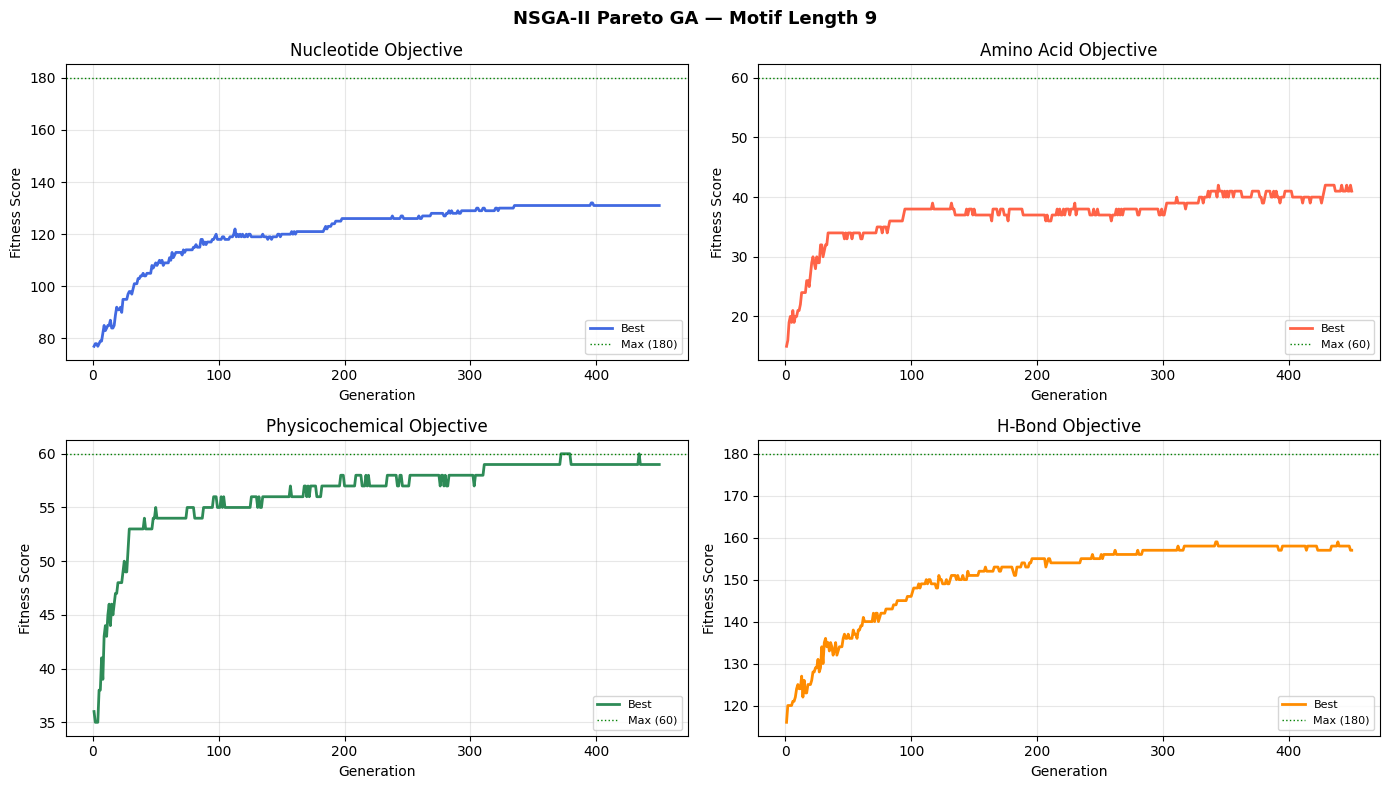

In [8]:
sequences = read_txt_and_return_lines("full_char_seq.txt")

POP_SIZE       = 300
NUM_GENERATIONS = 450
TOURNAMENT_SIZE = 2
MUTATION_RATE  = 0.3
ELITE_COUNT    = 2
MOTIF_LENGTH   = 9

if MOTIF_LENGTH % 3 != 0:
    raise ValueError(f"MOTIF_LENGTH must be divisible by 3. Got {MOTIF_LENGTH}.")

population = initialize_population(POP_SIZE, sequences, MOTIF_LENGTH)

pareto_chromosomes, pareto_fitnesses, history = run_ga_pareto(
    population, sequences, MOTIF_LENGTH, NUM_GENERATIONS,
    TOURNAMENT_SIZE, MUTATION_RATE, ELITE_COUNT
)

NAMES = ["Nucleotide", "Amino Acid", "Physicochemical", "H-Bond"]
print(f"Pareto front size: {len(pareto_chromosomes)} non-dominated solutions\n")
for i, (chrom, fits) in enumerate(zip(pareto_chromosomes, pareto_fitnesses)):
    scores = ", ".join(f"{n}={v}" for n, v in zip(NAMES, fits))
    print(f"Solution {i+1}: [{scores}]")

plot_pareto_convergence(history, MOTIF_LENGTH, NUM_GENERATIONS, sequences)


In [11]:
def plot_all_pareto_fronts(pareto_fitnesses):
    NAMES = ["Nucleotide", "Amino Acid", "Physicochemical", "H-Bond"]
    pairs = [(i, j) for i in range(4) for j in range(i+1, 4)]  # all 6 combos

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    axes = axes.flatten()

    for ax, (obj_x, obj_y) in zip(axes, pairs):
        xs = [f[obj_x] for f in pareto_fitnesses]
        ys = [f[obj_y] for f in pareto_fitnesses]
        ax.scatter(xs, ys, c="royalblue", edgecolors="navy", s=80, alpha=0.8)
        ax.set_xlabel(NAMES[obj_x])
        ax.set_ylabel(NAMES[obj_y])
        ax.set_title(f"{NAMES[obj_x]} vs {NAMES[obj_y]}")
        ax.grid(True, alpha=0.3)

    plt.suptitle("Pareto Front — All Objective Pairs", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("pareto_all_pairs.png", dpi=150)
    plt.show()

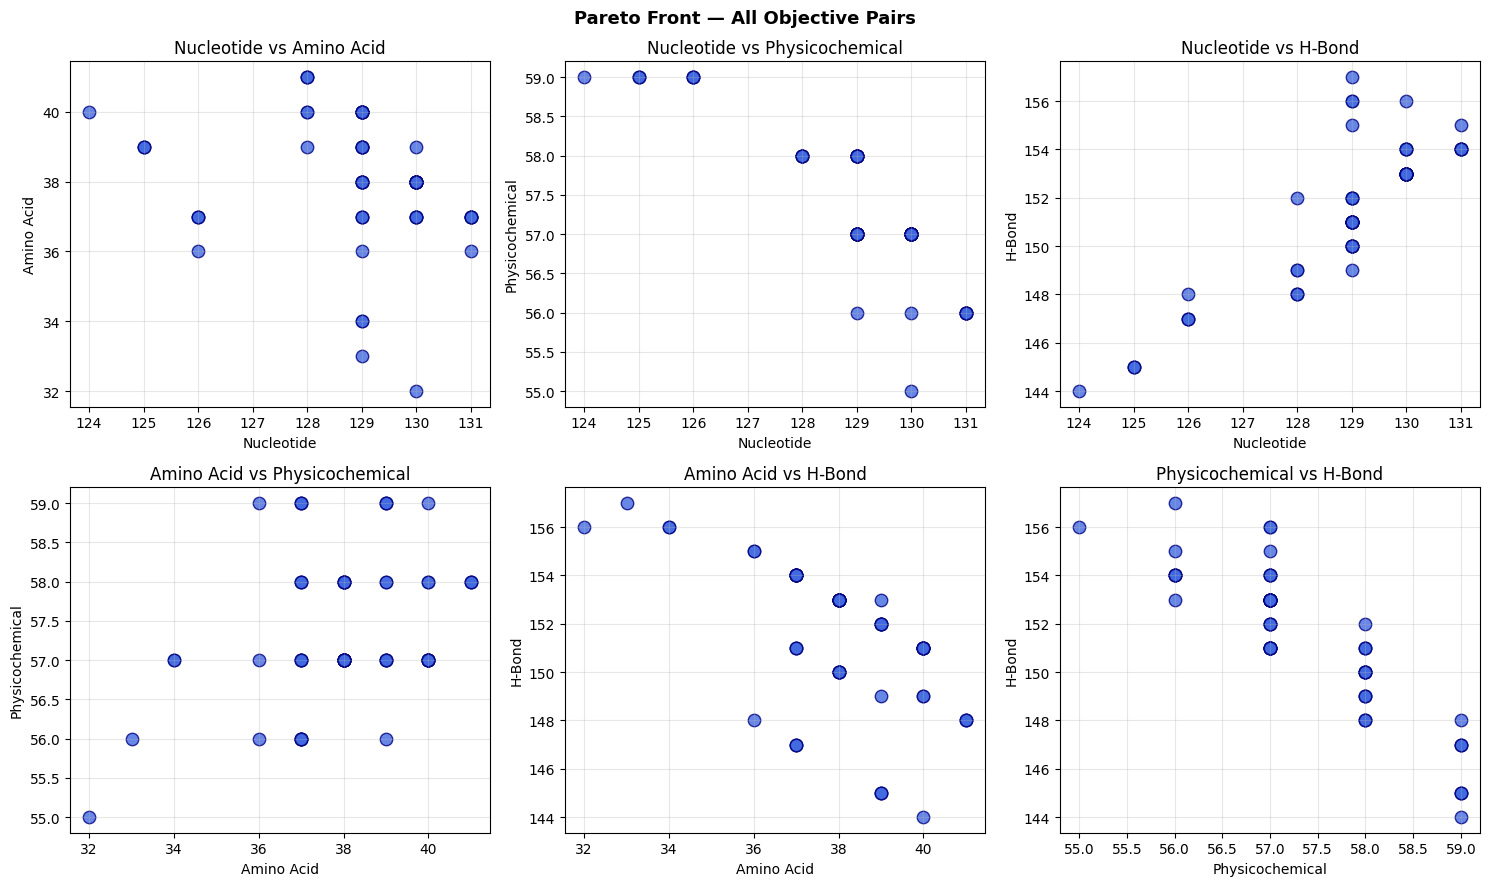

In [12]:
plot_all_pareto_fronts(pareto_fitnesses)